In [2]:
import sqlite3
import pandas as pd
import numpy as np
import os

In [5]:

# Define the CSV and database filenames
csv_file = "rebalanced_age_data.csv"
db_file = "bnpl_proxy_data.db"  # New database file

# Check if the CSV file exists
if not os.path.exists(csv_file):
    raise FileNotFoundError(f"CSV file '{csv_file}' not found.")

# Read the CSV file into a DataFrame
df = pd.read_csv(csv_file)

# Connect to (or create) the new SQLite database
conn = sqlite3.connect(db_file)

# Upload the DataFrame to the new table in the database.
# If the table exists, it will be replaced.
df.to_sql("bnpl_loans_with_age_change_three", conn, if_exists="replace", index=False)

# Optional: Verify that the table was created and print the number of rows.
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM bnpl_loans_with_age_change_three")
record_count = cursor.fetchone()[0]
print(f"Table 'bnpl_loans_with_age_change_three' created with {record_count} records.")

# Close the connection
conn.close()


/var/folders/bm/0wq19v017y79n8fk7_72tt4c0000gn/T/ipykernel_62720/2926977927.py:10: DtypeWarning: Columns (19,49,59,118,129,130,131,134,135,136,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


Table 'bnpl_loans_with_age_change_three' created with 184212 records.


In [13]:
source_db = 'loans.db'
target_db = 'bnpl_proxy_data.db'

# Connect to the source database and load the raw data into a DataFrame
source_conn = sqlite3.connect(source_db)
df_raw = pd.read_sql_query("SELECT * FROM bnpl_like_accepted_loans_limited_with_age_fico", source_conn)
source_conn.close()

# Connect to the target database (it will be created if it doesn't exist)
target_conn = sqlite3.connect(target_db)

# Upload the raw data into the new table "bnpl_loans_with_age"
df_raw.to_sql("bnpl_loans_with_age", target_conn, if_exists="replace", index=False)

# Optional: Verify that the data was transferred by checking row count
cursor = target_conn.cursor()
cursor.execute("SELECT COUNT(*) FROM bnpl_loans_with_age")
record_count = cursor.fetchone()[0]
print(f"Table 'bnpl_loans_with_age' created with {record_count} records.")

# Commit and close the connection
target_conn.commit()
target_conn.close()


Table 'bnpl_loans_with_age' created with 297291 records.


In [4]:
# Connect to the SQLite database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the BNPL-like accepted loans with age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Optional: Check overall distributions (uncomment to print summary statistics)
print(df['age_group'].value_counts().sort_index())
print(df['fico_range_high'].describe())
print(df['loan_amnt'].describe())

age_group
18-24    55112
25-33    55112
34-40    36741
41-50    18370
51-64    18348
65+        507
Name: count, dtype: int64
count    184212.000000
mean        698.153057
std          32.831296
min         614.000000
25%         674.000000
50%         689.000000
75%         714.000000
max         850.000000
Name: fico_range_high, dtype: float64
count    184212.000000
mean       3658.876186
std        1228.332970
min        1000.000000
25%        2800.000000
50%        4000.000000
75%        5000.000000
max        5000.000000
Name: loan_amnt, dtype: float64


In [5]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the BNPL-like accepted loans with age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Optional: Check overall distributions (uncomment to print summary statistics)
print("Age group counts:")
print(df['age_group'].value_counts().sort_index())
print("\nFICO score (fico_range_high) summary:")
print(df['fico_range_high'].describe())
print("\nLoan amount (loan_amnt) summary:")
print(df['loan_amnt'].describe())

# Group the data by age_group and compute aggregated statistics for loan amount and FICO score.
grouped_stats = df.groupby('age_group')[['loan_amnt', 'fico_range_high']].agg(
    mean=pd.NamedAgg(column='loan_amnt', aggfunc='mean'),
    median=pd.NamedAgg(column='loan_amnt', aggfunc='median'),
    std=pd.NamedAgg(column='loan_amnt', aggfunc='std'),
    count=pd.NamedAgg(column='loan_amnt', aggfunc='count')
)

# Because we want both loan amount and FICO score, we'll aggregate them separately and then combine:
loan_stats = df.groupby('age_group')['loan_amnt'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
fico_stats = df.groupby('age_group')['fico_range_high'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

# Combine the two aggregated DataFrames for a complete view.
combined_stats = pd.concat([loan_stats, fico_stats], axis=1, keys=['Loan Amount', 'FICO Score'])
combined_stats.columns = ['_'.join(col).strip() for col in combined_stats.columns.values]

print("\nAggregated statistics by age group (Loan Amount and FICO Score):")
print(combined_stats)

# Close the connection
conn.close()


Age group counts:
age_group
18-24    55112
25-33    55112
34-40    36741
41-50    18370
51-64    18348
65+        507
Name: count, dtype: int64

FICO score (fico_range_high) summary:
count    184212.000000
mean        698.153057
std          32.831296
min         614.000000
25%         674.000000
50%         689.000000
75%         714.000000
max         850.000000
Name: fico_range_high, dtype: float64

Loan amount (loan_amnt) summary:
count    184212.000000
mean       3658.876186
std        1228.332970
min        1000.000000
25%        2800.000000
50%        4000.000000
75%        5000.000000
max        5000.000000
Name: loan_amnt, dtype: float64

Aggregated statistics by age group (Loan Amount and FICO Score):
           Loan Amount_mean  Loan Amount_median  Loan Amount_std  \
age_group                                                          
18-24           3638.995591              4000.0      1229.842629   
25-33           3648.639588              4000.0      1225.844187   
34-40  

In [6]:
import sqlite3
import pandas as pd

# Connect to the database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the data from the table containing rebalanced age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Function to compute counts and percentages for a given column by age_group
def summarize_by_age(df, col_name):
    summary_list = []
    # Loop over each unique age group (skip any NaN)
    for age in df['age_group'].dropna().unique():
        subset = df[df['age_group'] == age]
        total = subset.shape[0]
        counts = subset[col_name].value_counts().sort_index()
        percentages = (counts / total * 100).round(2)
        temp_df = pd.DataFrame({
            'age_group': age,
            col_name: counts.index,
            'count': counts.values,
            'percentage': percentages.values
        })
        summary_list.append(temp_df)
    summary = pd.concat(summary_list, ignore_index=True)
    return summary

# Create summaries for grade and sub_grade
grade_summary = summarize_by_age(df, 'grade')
subgrade_summary = summarize_by_age(df, 'sub_grade')

print("Grade Summary by Age Group:")
print(grade_summary)

print("\nSub Grade Summary by Age Group:")
print(subgrade_summary)

conn.close()


Grade Summary by Age Group:
   age_group grade  count  percentage
0      25-33     A   8103       14.70
1      25-33     B  16616       30.15
2      25-33     C  17722       32.16
3      25-33     D   8973       16.28
4      25-33     E   2874        5.21
5      25-33     F    714        1.30
6      25-33     G    110        0.20
7      34-40     A   6485       17.65
8      34-40     B  12143       33.05
9      34-40     C  11119       30.26
10     34-40     D   5065       13.79
11     34-40     E   1557        4.24
12     34-40     F    323        0.88
13     34-40     G     49        0.13
14     18-24     A   7175       13.02
15     18-24     B  15878       28.81
16     18-24     C  18208       33.04
17     18-24     D   9484       17.21
18     18-24     E   3270        5.93
19     18-24     F    930        1.69
20     18-24     G    167        0.30
21     51-64     A   3673       20.02
22     51-64     B   6200       33.79
23     51-64     C   5246       28.59
24     51-64     D   2

In [7]:
import sqlite3
import pandas as pd

# Connect to the database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the data from the table containing rebalanced age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)
conn.close()

# Group the data by grade and calculate FICO score statistics
fico_by_grade = df.groupby('grade')['fico_range_low'].agg(
    min_fico='min',
    max_fico='max',
    mean_fico='mean',
    count='count'
)

# Calculate the range (difference between max and min)
fico_by_grade['fico_range'] = fico_by_grade['max_fico'] - fico_by_grade['min_fico']

print("FICO Score Summary by Grade:")
print(fico_by_grade)


FICO Score Summary by Grade:
       min_fico  max_fico   mean_fico  count  fico_range
grade                                                   
A         660.0     845.0  732.862072  29269       185.0
B         660.0     845.0  694.350775  57353       185.0
C         660.0     840.0  684.187901  57610       180.0
D         640.0     810.0  680.390230  28291       170.0
E         630.0     840.0  679.049779   9040       210.0
F         620.0     790.0  677.703412   2286       170.0
G         610.0     775.0  675.578512    363       165.0


In [9]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the BNPL-like accepted loans with age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change_two", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Optional: Check overall distributions (uncomment to print summary statistics)
print("Age group counts:")
print(df['age_group'].value_counts().sort_index())
print("\nFICO score (fico_range_high) summary:")
print(df['fico_range_high'].describe())
print("\nLoan amount (loan_amnt) summary:")
print(df['loan_amnt'].describe())

# Group the data by age_group and compute aggregated statistics for loan amount and FICO score.
grouped_stats = df.groupby('age_group')[['loan_amnt', 'fico_range_high']].agg(
    mean=pd.NamedAgg(column='loan_amnt', aggfunc='mean'),
    median=pd.NamedAgg(column='loan_amnt', aggfunc='median'),
    std=pd.NamedAgg(column='loan_amnt', aggfunc='std'),
    count=pd.NamedAgg(column='loan_amnt', aggfunc='count')
)

# Because we want both loan amount and FICO score, we'll aggregate them separately and then combine:
loan_stats = df.groupby('age_group')['loan_amnt'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
fico_stats = df.groupby('age_group')['fico_range_high'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

# Combine the two aggregated DataFrames for a complete view.
combined_stats = pd.concat([loan_stats, fico_stats], axis=1, keys=['Loan Amount', 'FICO Score'])
combined_stats.columns = ['_'.join(col).strip() for col in combined_stats.columns.values]

print("\nAggregated statistics by age group (Loan Amount and FICO Score):")
print(combined_stats)

# Close the connection
conn.close()

Age group counts:
age_group
18-24    27556
25-33    80287
34-40    36741
41-50    33054
51-64     6045
65+        507
Name: count, dtype: int64

FICO score (fico_range_high) summary:
count    184212.000000
mean        698.153057
std          32.831296
min         614.000000
25%         674.000000
50%         689.000000
75%         714.000000
max         850.000000
Name: fico_range_high, dtype: float64

Loan amount (loan_amnt) summary:
count    184212.000000
mean       3658.876186
std        1228.332970
min        1000.000000
25%        2800.000000
50%        4000.000000
75%        5000.000000
max        5000.000000
Name: loan_amnt, dtype: float64

Aggregated statistics by age group (Loan Amount and FICO Score):
           Loan Amount_mean  Loan Amount_median  Loan Amount_std  \
age_group                                                          
18-24           3630.585898              4000.0      1227.771116   
25-33           3646.733282              4000.0      1227.765527   
34-40  

In [12]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the BNPL-like accepted loans with age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change_three", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Optional: Check overall distributions (uncomment to print summary statistics)
print("Age group counts:")
print(df['age_group'].value_counts().sort_index())
print("\nFICO score (fico_range_high) summary:")
print(df['fico_range_high'].describe())
print("\nLoan amount (loan_amnt) summary:")
print(df['loan_amnt'].describe())

# Group the data by age_group and compute aggregated statistics for loan amount and FICO score.
grouped_stats = df.groupby('age_group')[['loan_amnt', 'fico_range_high']].agg(
    mean=pd.NamedAgg(column='loan_amnt', aggfunc='mean'),
    median=pd.NamedAgg(column='loan_amnt', aggfunc='median'),
    std=pd.NamedAgg(column='loan_amnt', aggfunc='std'),
    count=pd.NamedAgg(column='loan_amnt', aggfunc='count')
)

# Because we want both loan amount and FICO score, we'll aggregate them separately and then combine:
loan_stats = df.groupby('age_group')['loan_amnt'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
fico_stats = df.groupby('age_group')['fico_range_high'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

# Combine the two aggregated DataFrames for a complete view.
combined_stats = pd.concat([loan_stats, fico_stats], axis=1, keys=['Loan Amount', 'FICO Score'])
combined_stats.columns = ['_'.join(col).strip() for col in combined_stats.columns.values]

print("\nAggregated statistics by age group (Loan Amount and FICO Score):")
print(combined_stats)

# Close the connection
conn.close()

Age group counts:
age_group
18-24    45926
25-33    64297
34-40    45926
41-50    18370
51-64     9164
65+        507
Name: count, dtype: int64

FICO score (fico_range_high) summary:
count    184212.000000
mean        698.153057
std          32.831296
min         614.000000
25%         674.000000
50%         689.000000
75%         714.000000
max         850.000000
Name: fico_range_high, dtype: float64

Loan amount (loan_amnt) summary:
count    184212.000000
mean       3658.876186
std        1228.332970
min        1000.000000
25%        2800.000000
50%        4000.000000
75%        5000.000000
max        5000.000000
Name: loan_amnt, dtype: float64

Aggregated statistics by age group (Loan Amount and FICO Score):
           Loan Amount_mean  Loan Amount_median  Loan Amount_std  \
age_group                                                          
18-24           3636.971977              4000.0      1228.927004   
25-33           3648.714948              4000.0      1226.705742   
34-40  

In [6]:
# Load the BNPL-like accepted loans with age data
df = pd.read_csv("rebalanced_age_data_original.csv")

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Optional: Check overall distributions (uncomment to print summary statistics)
print("Age group counts:")
print(df['age_group'].value_counts().sort_index())
print("\nFICO score (fico_range_high) summary:")
print(df['fico_range_high'].describe())
print("\nLoan amount (loan_amnt) summary:")
print(df['loan_amnt'].describe())

# Group the data by age_group and compute aggregated statistics for loan amount and FICO score.
grouped_stats = df.groupby('age_group')[['loan_amnt', 'fico_range_high']].agg(
    mean=pd.NamedAgg(column='loan_amnt', aggfunc='mean'),
    median=pd.NamedAgg(column='loan_amnt', aggfunc='median'),
    std=pd.NamedAgg(column='loan_amnt', aggfunc='std'),
    count=pd.NamedAgg(column='loan_amnt', aggfunc='count')
)

# Because we want both loan amount and FICO score, we'll aggregate them separately and then combine:
loan_stats = df.groupby('age_group')['loan_amnt'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
fico_stats = df.groupby('age_group')['fico_range_high'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

# Combine the two aggregated DataFrames for a complete view.
combined_stats = pd.concat([loan_stats, fico_stats], axis=1, keys=['Loan Amount', 'FICO Score'])
combined_stats.columns = ['_'.join(col).strip() for col in combined_stats.columns.values]

print("\nAggregated statistics by age group (Loan Amount and FICO Score):")
print(combined_stats)

/var/folders/bm/0wq19v017y79n8fk7_72tt4c0000gn/T/ipykernel_33594/2826919846.py:2: DtypeWarning: Columns (19,49,59,118,129,130,131,134,135,136,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("rebalanced_age_data_original.csv")


Age group counts:
age_group
18-24    16262
25-33    91581
34-40    46788
41-50    23007
51-64     6045
65         507
Name: count, dtype: int64

FICO score (fico_range_high) summary:
count    184212.000000
mean        698.153057
std          32.831296
min         614.000000
25%         674.000000
50%         689.000000
75%         714.000000
max         850.000000
Name: fico_range_high, dtype: float64

Loan amount (loan_amnt) summary:
count    184212.000000
mean       3658.876186
std        1228.332970
min        1000.000000
25%        2800.000000
50%        4000.000000
75%        5000.000000
max        5000.000000
Name: loan_amnt, dtype: float64

Aggregated statistics by age group (Loan Amount and FICO Score):
           Loan Amount_mean  Loan Amount_median  Loan Amount_std  \
age_group                                                          
18-24           3597.368097              3925.0      1228.529771   
25-33           3650.640417              4000.0      1227.480941   
34-40  

In [13]:
import sqlite3
import pandas as pd

# Connect to the database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the data from the table containing rebalanced age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change_two", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Function to compute counts and percentages for a given column by age_group
def summarize_by_age(df, col_name):
    summary_list = []
    # Loop over each unique age group (skip any NaN)
    for age in df['age_group'].dropna().unique():
        subset = df[df['age_group'] == age]
        total = subset.shape[0]
        counts = subset[col_name].value_counts().sort_index()
        percentages = (counts / total * 100).round(2)
        temp_df = pd.DataFrame({
            'age_group': age,
            col_name: counts.index,
            'count': counts.values,
            'percentage': percentages.values
        })
        summary_list.append(temp_df)
    summary = pd.concat(summary_list, ignore_index=True)
    return summary

# Create summaries for grade and sub_grade
grade_summary = summarize_by_age(df, 'grade')
subgrade_summary = summarize_by_age(df, 'sub_grade')

print("Grade Summary by Age Group:")
print(grade_summary)

print("\nSub Grade Summary by Age Group:")
print(subgrade_summary)

conn.close()

Grade Summary by Age Group:
   age_group grade  count  percentage
0      25-33     A  11877       14.79
1      25-33     B  24142       30.07
2      25-33     C  25807       32.14
3      25-33     D  13021       16.22
4      25-33     E   4208        5.24
5      25-33     F   1063        1.32
6      25-33     G    169        0.21
7      34-40     A   6513       17.73
8      34-40     B  12128       33.01
9      34-40     C  11112       30.24
10     34-40     D   5085       13.84
11     34-40     E   1527        4.16
12     34-40     F    324        0.88
13     34-40     G     52        0.14
14     18-24     A   2984       10.83
15     18-24     B   7528       27.32
16     18-24     C   9417       34.17
17     18-24     D   5131       18.62
18     18-24     E   1838        6.67
19     18-24     F    555        2.01
20     18-24     G    103        0.37
21     41-50     A   6417       19.41
22     41-50     B  11276       34.11
23     41-50     C   9481       28.68
24     41-50     D   4

In [7]:
# Load the data from the table containing rebalanced age data
df = pd.read_csv("rebalanced_age_data_original.csv")

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Function to compute counts and percentages for a given column by age_group
def summarize_by_age(df, col_name):
    summary_list = []
    # Loop over each unique age group (skip any NaN)
    for age in df['age_group'].dropna().unique():
        subset = df[df['age_group'] == age]
        total = subset.shape[0]
        counts = subset[col_name].value_counts().sort_index()
        percentages = (counts / total * 100).round(2)
        temp_df = pd.DataFrame({
            'age_group': age,
            col_name: counts.index,
            'count': counts.values,
            'percentage': percentages.values
        })
        summary_list.append(temp_df)
    summary = pd.concat(summary_list, ignore_index=True)
    return summary

# Create summaries for grade and sub_grade
grade_summary = summarize_by_age(df, 'grade')
subgrade_summary = summarize_by_age(df, 'sub_grade')

print("Grade Summary by Age Group:")
print(grade_summary)

print("\nSub Grade Summary by Age Group:")
print(subgrade_summary)

/var/folders/bm/0wq19v017y79n8fk7_72tt4c0000gn/T/ipykernel_33594/1163170600.py:2: DtypeWarning: Columns (19,49,59,118,129,130,131,134,135,136,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("rebalanced_age_data_original.csv")


Grade Summary by Age Group:
   age_group grade  count  percentage
0      25-33     A  13543       14.79
1      25-33     B  27522       30.05
2      25-33     C  29453       32.16
3      25-33     D  14823       16.19
4      25-33     E   4817        5.26
5      25-33     F   1226        1.34
6      25-33     G    197        0.22
7      34-40     A   8280       17.70
8      34-40     B  15462       33.05
9      34-40     C  14124       30.19
10     34-40     D   6499       13.89
11     34-40     E   1949        4.17
12     34-40     F    410        0.88
13     34-40     G     64        0.14
14     18-24     A   1318        8.10
15     18-24     B   4148       25.51
16     18-24     C   5771       35.49
17     18-24     D   3329       20.47
18     18-24     E   1229        7.56
19     18-24     F    392        2.41
20     18-24     G     75        0.46
21     41-50     A   4650       20.21
22     41-50     B   7942       34.52
23     41-50     C   6469       28.12
24     41-50     D   2

In [14]:
import sqlite3
import pandas as pd

# Connect to the database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the data from the table containing rebalanced age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change_three", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Function to compute counts and percentages for a given column by age_group
def summarize_by_age(df, col_name):
    summary_list = []
    # Loop over each unique age group (skip any NaN)
    for age in df['age_group'].dropna().unique():
        subset = df[df['age_group'] == age]
        total = subset.shape[0]
        counts = subset[col_name].value_counts().sort_index()
        percentages = (counts / total * 100).round(2)
        temp_df = pd.DataFrame({
            'age_group': age,
            col_name: counts.index,
            'count': counts.values,
            'percentage': percentages.values
        })
        summary_list.append(temp_df)
    summary = pd.concat(summary_list, ignore_index=True)
    return summary

# Create summaries for grade and sub_grade
grade_summary = summarize_by_age(df, 'grade')
subgrade_summary = summarize_by_age(df, 'sub_grade')

print("Grade Summary by Age Group:")
print(grade_summary)

print("\nSub Grade Summary by Age Group:")
print(subgrade_summary)

conn.close()

Grade Summary by Age Group:
   age_group grade  count  percentage
0      25-33     A   9497       14.77
1      25-33     B  19356       30.10
2      25-33     C  20631       32.09
3      25-33     D  10497       16.33
4      25-33     E   3342        5.20
5      25-33     F    842        1.31
6      25-33     G    132        0.21
7      34-40     A   8122       17.68
8      34-40     B  15180       33.05
9      34-40     C  13880       30.22
10     34-40     D   6371       13.87
11     34-40     E   1916        4.17
12     34-40     F    395        0.86
13     34-40     G     62        0.13
14     18-24     A   5842       12.72
15     18-24     B  13127       28.58
16     18-24     C  15247       33.20
17     18-24     D   7976       17.37
18     18-24     E   2789        6.07
19     18-24     F    802        1.75
20     18-24     G    143        0.31
21     41-50     A   3720       20.25
22     41-50     B   6345       34.54
23     41-50     C   5192       28.26
24     41-50     D   2

In [15]:
import sqlite3
import pandas as pd

# Connect to the database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the data from the table containing rebalanced age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Function to compute counts and percentages for a given column by age_group
def summarize_by_age(df, col_name):
    summary_list = []
    # Loop over each unique age group (skip any NaN)
    for age in df['age_group'].dropna().unique():
        subset = df[df['age_group'] == age]
        total = subset.shape[0]
        counts = subset[col_name].value_counts().sort_index()
        percentages = (counts / total * 100).round(2)
        temp_df = pd.DataFrame({
            'age_group': age,
            col_name: counts.index,
            'count': counts.values,
            'percentage': percentages.values
        })
        summary_list.append(temp_df)
    summary = pd.concat(summary_list, ignore_index=True)
    return summary

# Create summaries for grade and sub_grade
default_indicator_summary = summarize_by_age(df, 'default_indicator')

print("Default by Age Group:")
print(default_indicator_summary)

conn.close()

Default by Age Group:
   age_group  default_indicator  count  percentage
0      25-33                  0  45709       82.94
1      25-33                  1   9403       17.06
2      34-40                  0  30940       84.21
3      34-40                  1   5801       15.79
4      18-24                  0  45355       82.30
5      18-24                  1   9757       17.70
6      51-64                  0  15285       83.31
7      51-64                  1   3063       16.69
8      41-50                  0  15509       84.43
9      41-50                  1   2861       15.57
10       65+                  0    371       73.18
11       65+                  1    136       26.82


In [16]:
import sqlite3
import pandas as pd

# Connect to the database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the data from the table containing rebalanced age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change_two", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Function to compute counts and percentages for a given column by age_group
def summarize_by_age(df, col_name):
    summary_list = []
    # Loop over each unique age group (skip any NaN)
    for age in df['age_group'].dropna().unique():
        subset = df[df['age_group'] == age]
        total = subset.shape[0]
        counts = subset[col_name].value_counts().sort_index()
        percentages = (counts / total * 100).round(2)
        temp_df = pd.DataFrame({
            'age_group': age,
            col_name: counts.index,
            'count': counts.values,
            'percentage': percentages.values
        })
        summary_list.append(temp_df)
    summary = pd.concat(summary_list, ignore_index=True)
    return summary

# Create summaries for grade and sub_grade
default_indicator_summary = summarize_by_age(df, 'default_indicator')

print("Default by Age Group:")
print(default_indicator_summary)

conn.close()

Default by Age Group:
   age_group  default_indicator  count  percentage
0      25-33                  0  66530       82.87
1      25-33                  1  13757       17.13
2      34-40                  0  30955       84.25
3      34-40                  1   5786       15.75
4      18-24                  0  22512       81.70
5      18-24                  1   5044       18.30
6      41-50                  0  27851       84.26
7      41-50                  1   5203       15.74
8      51-64                  0   4950       81.89
9      51-64                  1   1095       18.11
10       65+                  0    371       73.18
11       65+                  1    136       26.82


In [17]:
import sqlite3
import pandas as pd

# Connect to the database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the data from the table containing rebalanced age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change_three", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Function to compute counts and percentages for a given column by age_group
def summarize_by_age(df, col_name):
    summary_list = []
    # Loop over each unique age group (skip any NaN)
    for age in df['age_group'].dropna().unique():
        subset = df[df['age_group'] == age]
        total = subset.shape[0]
        counts = subset[col_name].value_counts().sort_index()
        percentages = (counts / total * 100).round(2)
        temp_df = pd.DataFrame({
            'age_group': age,
            col_name: counts.index,
            'count': counts.values,
            'percentage': percentages.values
        })
        summary_list.append(temp_df)
    summary = pd.concat(summary_list, ignore_index=True)
    return summary

# Create summaries for grade and sub_grade
default_indicator_summary = summarize_by_age(df, 'default_indicator')

print("Default by Age Group:")
print(default_indicator_summary)

conn.close()

Default by Age Group:
   age_group  default_indicator  count  percentage
0      25-33                  0  53324       82.93
1      25-33                  1  10973       17.07
2      34-40                  0  38660       84.18
3      34-40                  1   7266       15.82
4      18-24                  0  37730       82.15
5      18-24                  1   8196       17.85
6      41-50                  0  15487       84.31
7      41-50                  1   2883       15.69
8      51-64                  0   7597       82.90
9      51-64                  1   1567       17.10
10       65+                  0    371       73.18
11       65+                  1    136       26.82


In [3]:
import pandas as pd
df = pd.read_csv("rebalanced_age_data_original.csv")

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Function to compute counts and percentages for a given column by age_group
def summarize_by_age(df, col_name):
    summary_list = []
    # Loop over each unique age group (skip any NaN)
    for age in df['age_group'].dropna().unique():
        subset = df[df['age_group'] == age]
        total = subset.shape[0]
        counts = subset[col_name].value_counts().sort_index()
        percentages = (counts / total * 100).round(2)
        temp_df = pd.DataFrame({
            'age_group': age,
            col_name: counts.index,
            'count': counts.values,
            'percentage': percentages.values
        })
        summary_list.append(temp_df)
    summary = pd.concat(summary_list, ignore_index=True)
    return summary

# Create summaries for grade and sub_grade
default_indicator_summary = summarize_by_age(df, 'default_indicator')

print("Default by Age Group:")
print(default_indicator_summary)

/var/folders/bm/0wq19v017y79n8fk7_72tt4c0000gn/T/ipykernel_33594/1151218653.py:2: DtypeWarning: Columns (19,49,59,118,129,130,131,134,135,136,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("rebalanced_age_data_original.csv")


Default by Age Group:
   age_group  default_indicator  count  percentage
0      25-33                  0  75884       82.86
1      25-33                  1  15697       17.14
2      34-40                  0  39393       84.19
3      34-40                  1   7395       15.81
4      18-24                  0  13158       80.91
5      18-24                  1   3104       19.09
6      41-50                  0  19413       84.38
7      41-50                  1   3594       15.62
8      51-64                  0   4950       81.89
9      51-64                  1   1095       18.11
10        65                  0    371       73.18
11        65                  1    136       26.82


In [4]:
# Load the data from the table containing rebalanced age data
df = pd.read_csv("rebalanced_age_data_original.csv")

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Function to compute counts and percentages for a given column by age_group
def summarize_by_age(df, col_name):
    summary_list = []
    # Loop over each unique age group (skip any NaN)
    for age in df['age_group'].dropna().unique():
        subset = df[df['age_group'] == age]
        total = subset.shape[0]
        counts = subset[col_name].value_counts().sort_index()
        percentages = (counts / total * 100).round(2)
        temp_df = pd.DataFrame({
            'age_group': age,
            col_name: counts.index,
            'count': counts.values,
            'percentage': percentages.values
        })
        summary_list.append(temp_df)
    summary = pd.concat(summary_list, ignore_index=True)
    return summary

# Create summaries for grade and sub_grade
default_indicator_summary = summarize_by_age(df, 'fico_bucket_pct')

print("Default by Age Group:")
print(default_indicator_summary)

/var/folders/bm/0wq19v017y79n8fk7_72tt4c0000gn/T/ipykernel_33594/2502681551.py:2: DtypeWarning: Columns (19,49,59,118,129,130,131,134,135,136,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("rebalanced_age_data_original.csv")


Default by Age Group:
   age_group fico_bucket_pct  count  percentage
0      25-33   Deep Subprime  43823       47.85
1      25-33      Near Prime  11355       12.40
2      25-33           Prime  11517       12.58
3      25-33        Subprime  16707       18.24
4      25-33     Super-prime   8179        8.93
5      34-40   Deep Subprime  22159       47.36
6      34-40      Near Prime   5744       12.28
7      34-40           Prime   6080       12.99
8      34-40        Subprime   8128       17.37
9      34-40     Super-prime   4677       10.00
10     18-24   Deep Subprime   7104       43.68
11     18-24      Near Prime   2181       13.41
12     18-24           Prime   2805       17.25
13     18-24        Subprime   3001       18.45
14     18-24     Super-prime   1171        7.20
15     41-50   Deep Subprime  10608       46.11
16     41-50      Near Prime   2839       12.34
17     41-50           Prime   3067       13.33
18     41-50        Subprime   3823       16.62
19     41-50     S

In [18]:
import sqlite3
import pandas as pd

# Connect to the database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the data from the table containing rebalanced age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Function to compute counts and percentages for a given column by age_group
def summarize_by_age(df, col_name):
    summary_list = []
    # Loop over each unique age group (skip any NaN)
    for age in df['age_group'].dropna().unique():
        subset = df[df['age_group'] == age]
        total = subset.shape[0]
        counts = subset[col_name].value_counts().sort_index()
        percentages = (counts / total * 100).round(2)
        temp_df = pd.DataFrame({
            'age_group': age,
            col_name: counts.index,
            'count': counts.values,
            'percentage': percentages.values
        })
        summary_list.append(temp_df)
    summary = pd.concat(summary_list, ignore_index=True)
    return summary

# Create summaries for grade and sub_grade
default_indicator_summary = summarize_by_age(df, 'fico_bucket_pct')

print("Default by Age Group:")
print(default_indicator_summary)

conn.close()

Default by Age Group:
   age_group fico_bucket_pct  count  percentage
0      25-33   Deep Subprime  26386       47.88
1      25-33      Near Prime   6793       12.33
2      25-33           Prime   6932       12.58
3      25-33        Subprime  10110       18.34
4      25-33     Super-prime   4891        8.87
5      34-40   Deep Subprime  17447       47.49
6      34-40      Near Prime   4507       12.27
7      34-40           Prime   4727       12.87
8      34-40        Subprime   6370       17.34
9      34-40     Super-prime   3690       10.04
10     18-24   Deep Subprime  25639       46.52
11     18-24      Near Prime   7022       12.74
12     18-24           Prime   7712       13.99
13     18-24        Subprime  10044       18.22
14     18-24     Super-prime   4695        8.52
15     51-64   Deep Subprime   8467       46.15
16     51-64      Near Prime   2204       12.01
17     51-64           Prime   2466       13.44
18     51-64        Subprime   3133       17.08
19     51-64     S

In [19]:
import sqlite3
import pandas as pd

# Connect to the database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the data from the table containing rebalanced age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change_two", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Function to compute counts and percentages for a given column by age_group
def summarize_by_age(df, col_name):
    summary_list = []
    # Loop over each unique age group (skip any NaN)
    for age in df['age_group'].dropna().unique():
        subset = df[df['age_group'] == age]
        total = subset.shape[0]
        counts = subset[col_name].value_counts().sort_index()
        percentages = (counts / total * 100).round(2)
        temp_df = pd.DataFrame({
            'age_group': age,
            col_name: counts.index,
            'count': counts.values,
            'percentage': percentages.values
        })
        summary_list.append(temp_df)
    summary = pd.concat(summary_list, ignore_index=True)
    return summary

# Create summaries for grade and sub_grade
default_indicator_summary = summarize_by_age(df, 'fico_bucket_pct')

print("Default by Age Group:")
print(default_indicator_summary)

conn.close()

Default by Age Group:
   age_group fico_bucket_pct  count  percentage
0      25-33   Deep Subprime  38392       47.82
1      25-33      Near Prime   9975       12.42
2      25-33           Prime  10079       12.55
3      25-33        Subprime  14670       18.27
4      25-33     Super-prime   7171        8.93
5      34-40   Deep Subprime  17435       47.45
6      34-40      Near Prime   4540       12.36
7      34-40           Prime   4772       12.99
8      34-40        Subprime   6314       17.19
9      34-40     Super-prime   3680       10.02
10     18-24   Deep Subprime  12535       45.49
11     18-24      Near Prime   3561       12.92
12     18-24           Prime   4243       15.40
13     18-24        Subprime   5038       18.28
14     18-24     Super-prime   2179        7.91
15     41-50   Deep Subprime  15332       46.38
16     41-50      Near Prime   4043       12.23
17     41-50           Prime   4375       13.24
18     41-50        Subprime   5637       17.05
19     41-50     S

In [20]:
import sqlite3
import pandas as pd

# Connect to the database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load the data from the table containing rebalanced age data
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change_three", conn)

# Ensure we have the age_group column (if not, create it)
bins = [18, 24, 33, 40, 50, 64, 65]
labels = ["18-24", "25-33", "34-40", "41-50", "51-64", "65"]
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['approx_age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Function to compute counts and percentages for a given column by age_group
def summarize_by_age(df, col_name):
    summary_list = []
    # Loop over each unique age group (skip any NaN)
    for age in df['age_group'].dropna().unique():
        subset = df[df['age_group'] == age]
        total = subset.shape[0]
        counts = subset[col_name].value_counts().sort_index()
        percentages = (counts / total * 100).round(2)
        temp_df = pd.DataFrame({
            'age_group': age,
            col_name: counts.index,
            'count': counts.values,
            'percentage': percentages.values
        })
        summary_list.append(temp_df)
    summary = pd.concat(summary_list, ignore_index=True)
    return summary

# Create summaries for grade and sub_grade
default_indicator_summary = summarize_by_age(df, 'fico_bucket_pct')

print("Default by Age Group:")
print(default_indicator_summary)

conn.close()

Default by Age Group:
   age_group fico_bucket_pct  count  percentage
0      25-33   Deep Subprime  30773       47.86
1      25-33      Near Prime   7922       12.32
2      25-33           Prime   8071       12.55
3      25-33        Subprime  11773       18.31
4      25-33     Super-prime   5758        8.96
5      34-40   Deep Subprime  21756       47.37
6      34-40      Near Prime   5641       12.28
7      34-40           Prime   5982       13.03
8      34-40        Subprime   7964       17.34
9      34-40     Super-prime   4583        9.98
10     18-24   Deep Subprime  21262       46.30
11     18-24      Near Prime   5907       12.86
12     18-24           Prime   6533       14.23
13     18-24        Subprime   8349       18.18
14     18-24     Super-prime   3875        8.44
15     41-50   Deep Subprime   8464       46.08
16     41-50      Near Prime   2289       12.46
17     41-50           Prime   2483       13.52
18     41-50        Subprime   3038       16.54
19     41-50     S

In [21]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

# Load data from the table that contains the loan information
df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)

# Get the counts of each unique value in the loan_status column
loan_status_counts = df['verification_status'].value_counts().sort_index()

print("Loan Status Counts:")
print(loan_status_counts)

# (Optional) Save the results to a CSV file
loan_status_counts.to_csv("loan_status_counts.csv", header=["count"])

conn.close()

Loan Status Counts:
verification_status
Not Verified       72502
Source Verified    64348
Verified           47362
Name: count, dtype: int64


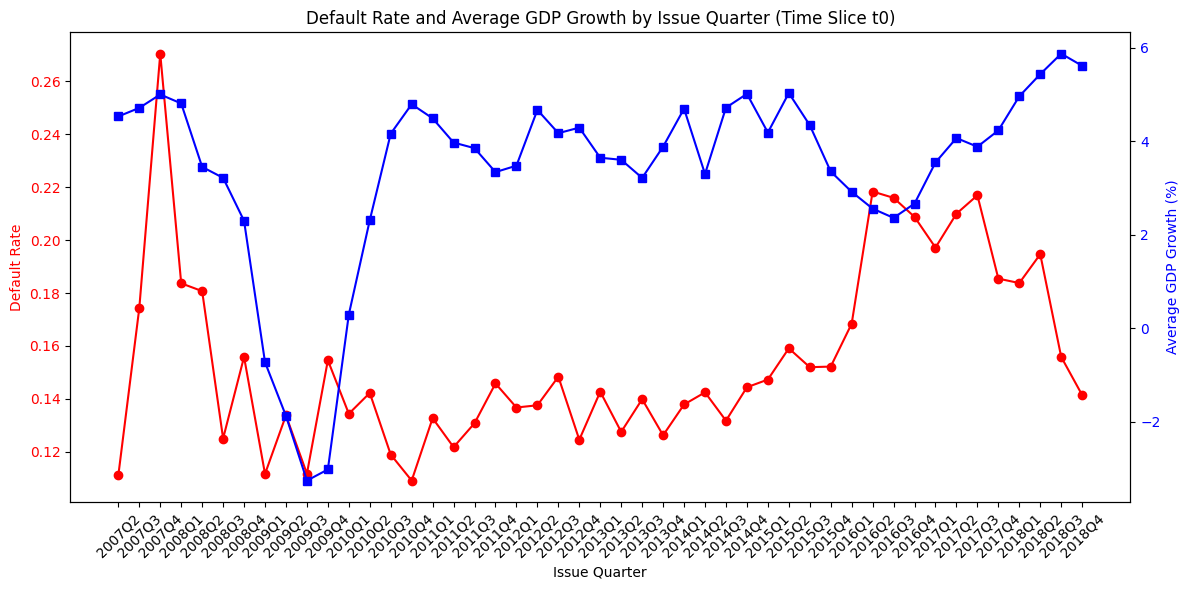

<Figure size 640x480 with 0 Axes>

In [1]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

# Connect to the SQLite database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)

# Aggregate data by issue_quarter.
agg_data = df.groupby('issue_quarter').agg({
    'default_indicator': 'mean',  # Average default rate per quarter
    'gdp_growth_t1': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(agg_data['issue_quarter'], agg_data['default_indicator'], color='red', marker='o', label='Default Rate')
ax1.set_xlabel("Issue Quarter")
ax1.set_ylabel("Default Rate", color='red')
ax1.tick_params(axis='y', labelcolor='red')
plt.xticks(rotation=45)

# Create a second y-axis for GDP.
ax2 = ax1.twinx()
ax2.plot(agg_data['issue_quarter'], agg_data['gdp_growth_t1'], color='blue', marker='s', label='Average GDP Growth (t0)')
ax2.set_ylabel("Average GDP Growth (%)", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Default Rate and Average GDP Growth by Issue Quarter (Time Slice t0)")
fig.tight_layout()
plt.show()
plt.savefig("default_rate_gdp_growth.png")

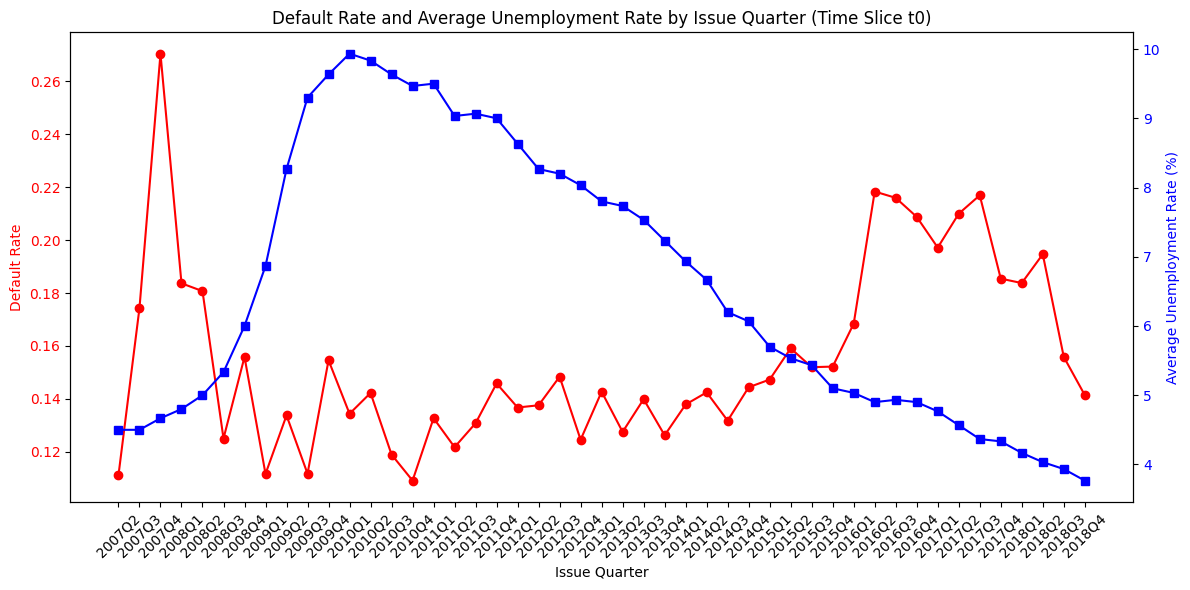

<Figure size 640x480 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

# Connect to the SQLite database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)

# Aggregate data by issue_quarter.
agg_data = df.groupby('issue_quarter').agg({
    'default_indicator': 'mean',  # Average default rate per quarter
    'gdp_growth_t1': 'mean',
    'unemployment_rate_t1': 'mean',
    'inflation_t1': 'mean',
    'fedfunds_t1': 'mean',
    "housing_price_t1": 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(agg_data['issue_quarter'], agg_data['default_indicator'], color='red', marker='o', label='Default Rate')
ax1.set_xlabel("Issue Quarter")
ax1.set_ylabel("Default Rate", color='red')
ax1.tick_params(axis='y', labelcolor='red')
plt.xticks(rotation=45)

# Create a second y-axis for GDP.
ax2 = ax1.twinx()
ax2.plot(agg_data['issue_quarter'], agg_data['unemployment_rate_t1'], color='blue', marker='s', label='Average Unemployment Rate (t0)')
ax2.set_ylabel("Average Unemployment Rate (%)", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Default Rate and Average Unemployment Rate by Issue Quarter (Time Slice t0)")
fig.tight_layout()
plt.show()
plt.savefig("default_rate_gdp_growth.png")

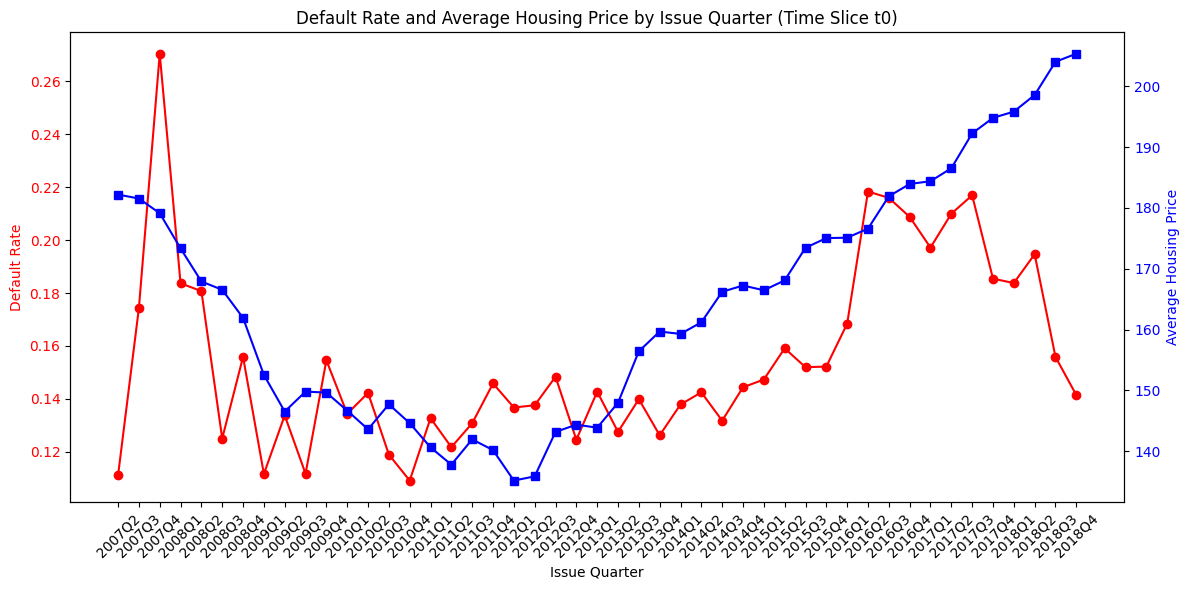

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

# Connect to the SQLite database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)

# Aggregate data by issue_quarter.
agg_data = df.groupby('issue_quarter').agg({
    'default_indicator': 'mean',  # Average default rate per quarter
    'gdp_growth_t1': 'mean',
    'unemployment_rate_t1': 'mean',
    'inflation_t1': 'mean',
    'fedfunds_t1': 'mean',
    "housing_price_t1": 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(agg_data['issue_quarter'], agg_data['default_indicator'], color='red', marker='o', label='Default Rate')
ax1.set_xlabel("Issue Quarter")
ax1.set_ylabel("Default Rate", color='red')
ax1.tick_params(axis='y', labelcolor='red')
plt.xticks(rotation=45)

# Create a second y-axis for GDP.
ax2 = ax1.twinx()
ax2.plot(agg_data['issue_quarter'], agg_data['housing_price_t1'], color='blue', marker='s', label='Average Housing Price (t0)')
ax2.set_ylabel("Average Housing Price", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Default Rate and Average Housing Price by Issue Quarter (Time Slice t0)")
fig.tight_layout()
plt.show()
plt.savefig("default_rate_gdp_growth.png")

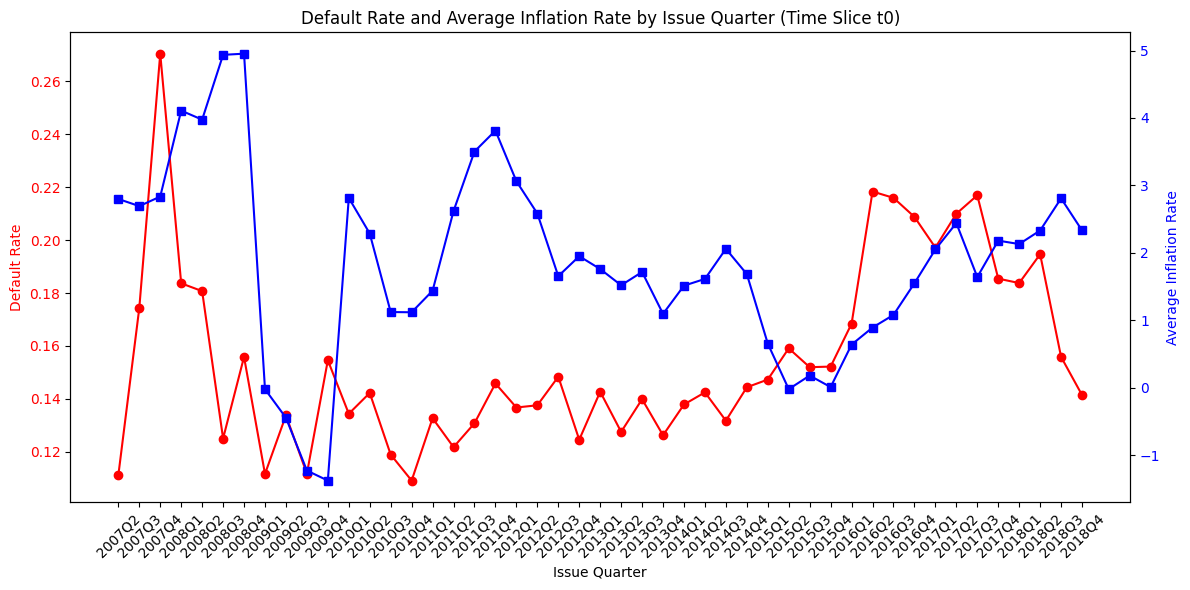

<Figure size 640x480 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

# Connect to the SQLite database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)

# Aggregate data by issue_quarter.
agg_data = df.groupby('issue_quarter').agg({
    'default_indicator': 'mean',  # Average default rate per quarter
    'gdp_growth_t1': 'mean',
    'unemployment_rate_t1': 'mean',
    'inflation_t1': 'mean',
    'fedfunds_t1': 'mean',
    "housing_price_t1": 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(agg_data['issue_quarter'], agg_data['default_indicator'], color='red', marker='o', label='Default Rate')
ax1.set_xlabel("Issue Quarter")
ax1.set_ylabel("Default Rate", color='red')
ax1.tick_params(axis='y', labelcolor='red')
plt.xticks(rotation=45)

# Create a second y-axis for GDP.
ax2 = ax1.twinx()
ax2.plot(agg_data['issue_quarter'], agg_data['inflation_t1'], color='blue', marker='s', label='Average Inflation Rate (t0)')
ax2.set_ylabel("Average Inflation Rate", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Default Rate and Average Inflation Rate by Issue Quarter (Time Slice t0)")
fig.tight_layout()
plt.show()
plt.savefig("default_rate_gdp_growth.png")

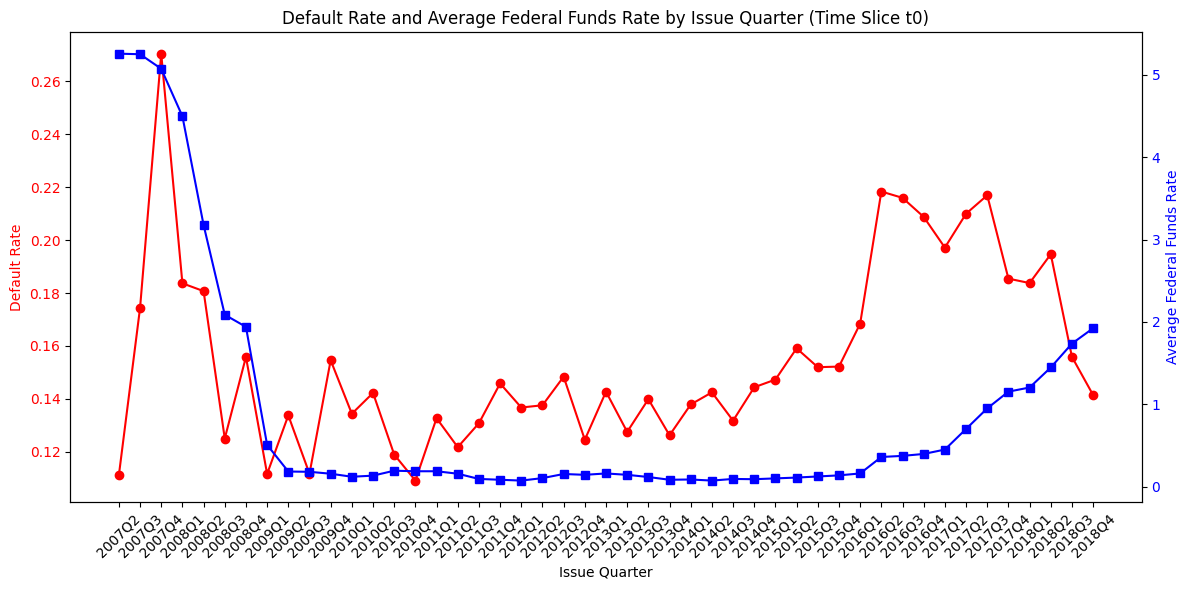

<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

# Connect to the SQLite database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)

# Aggregate data by issue_quarter.
agg_data = df.groupby('issue_quarter').agg({
    'default_indicator': 'mean',  # Average default rate per quarter
    'gdp_growth_t1': 'mean',
    'unemployment_rate_t1': 'mean',
    'inflation_t1': 'mean',
    'fedfunds_t1': 'mean',
    "housing_price_t1": 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(agg_data['issue_quarter'], agg_data['default_indicator'], color='red', marker='o', label='Default Rate')
ax1.set_xlabel("Issue Quarter")
ax1.set_ylabel("Default Rate", color='red')
ax1.tick_params(axis='y', labelcolor='red')
plt.xticks(rotation=45)

# Create a second y-axis for GDP.
ax2 = ax1.twinx()
ax2.plot(agg_data['issue_quarter'], agg_data['fedfunds_t1'], color='blue', marker='s', label='Federal Funds Rate (t0)')
ax2.set_ylabel("Average Federal Funds Rate", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Default Rate and Average Federal Funds Rate by Issue Quarter (Time Slice t0)")
fig.tight_layout()
plt.show()
plt.savefig("default_rate_gdp_growth.png")

In [ ]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

# Connect to the SQLite database
db_filename = 'bnpl_proxy_data.db'
conn = sqlite3.connect(db_filename)

df = pd.read_sql_query("SELECT * FROM bnpl_loans_with_age_change", conn)

# Aggregate data by issue_quarter.
agg_data = df.groupby('issue_quarter').agg({
    'default_indicator': 'mean',  # Average default rate per quarter
    'gdp_growth_t1': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(agg_data['issue_quarter'], agg_data['default_indicator'], color='red', marker='o', label='Default Rate')
ax1.set_xlabel("Issue Quarter")
ax1.set_ylabel("Default Rate", color='red')
ax1.tick_params(axis='y', labelcolor='red')
plt.xticks(rotation=45)

# Create a second y-axis for GDP.
ax2 = ax1.twinx()
ax2.plot(agg_data['issue_quarter'], agg_data['gdp_growth_t1'], color='blue', marker='s', label='Average GDP Growth (t0)')
ax2.set_ylabel("Average GDP Growth (%)", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Default Rate and Average GDP Growth by Issue Quarter (Time Slice t0)")
fig.tight_layout()
plt.show()
plt.savefig("default_rate_gdp_growth.png")

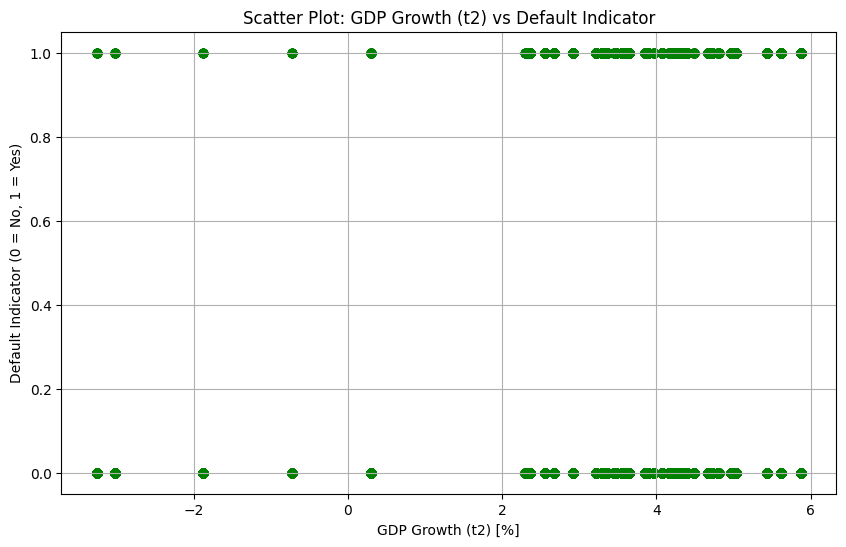

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df['gdp_growth_t2'], df['default_indicator'], alpha=0.5, c='green')
plt.xlabel("GDP Growth (t2) [%]")
plt.ylabel("Default Indicator (0 = No, 1 = Yes)")
plt.title("Scatter Plot: GDP Growth (t2) vs Default Indicator")
plt.grid(True)
plt.show()


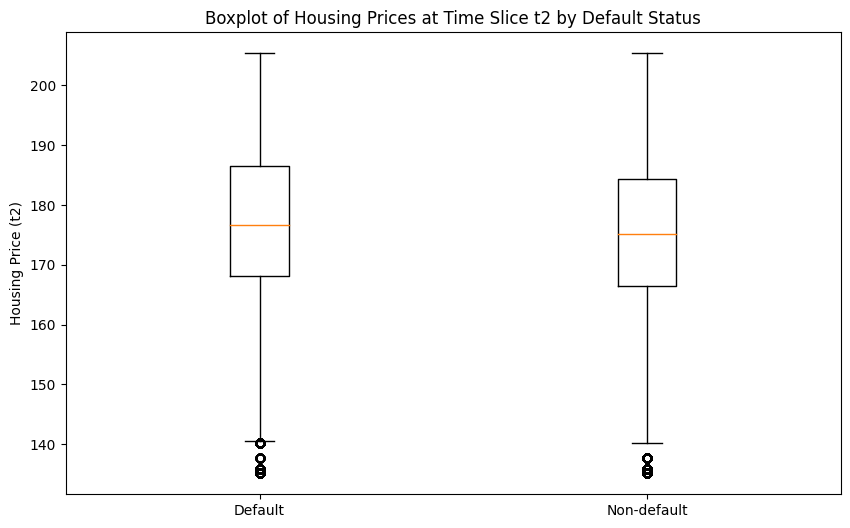

In [8]:
# Create a new column for default status label.
df['default_status'] = df['default_indicator'].apply(lambda x: "Default" if x == 1 else "Non-default")

# Prepare data for the boxplot.
housing_data = [
    df.loc[df['default_status'] == "Default", 'housing_price_t2'],
    df.loc[df['default_status'] == "Non-default", 'housing_price_t2']
]

plt.figure(figsize=(10, 6))
plt.boxplot(housing_data, labels=["Default", "Non-default"])
plt.ylabel("Housing Price (t2)")
plt.title("Boxplot of Housing Prices at Time Slice t2 by Default Status")
plt.show()


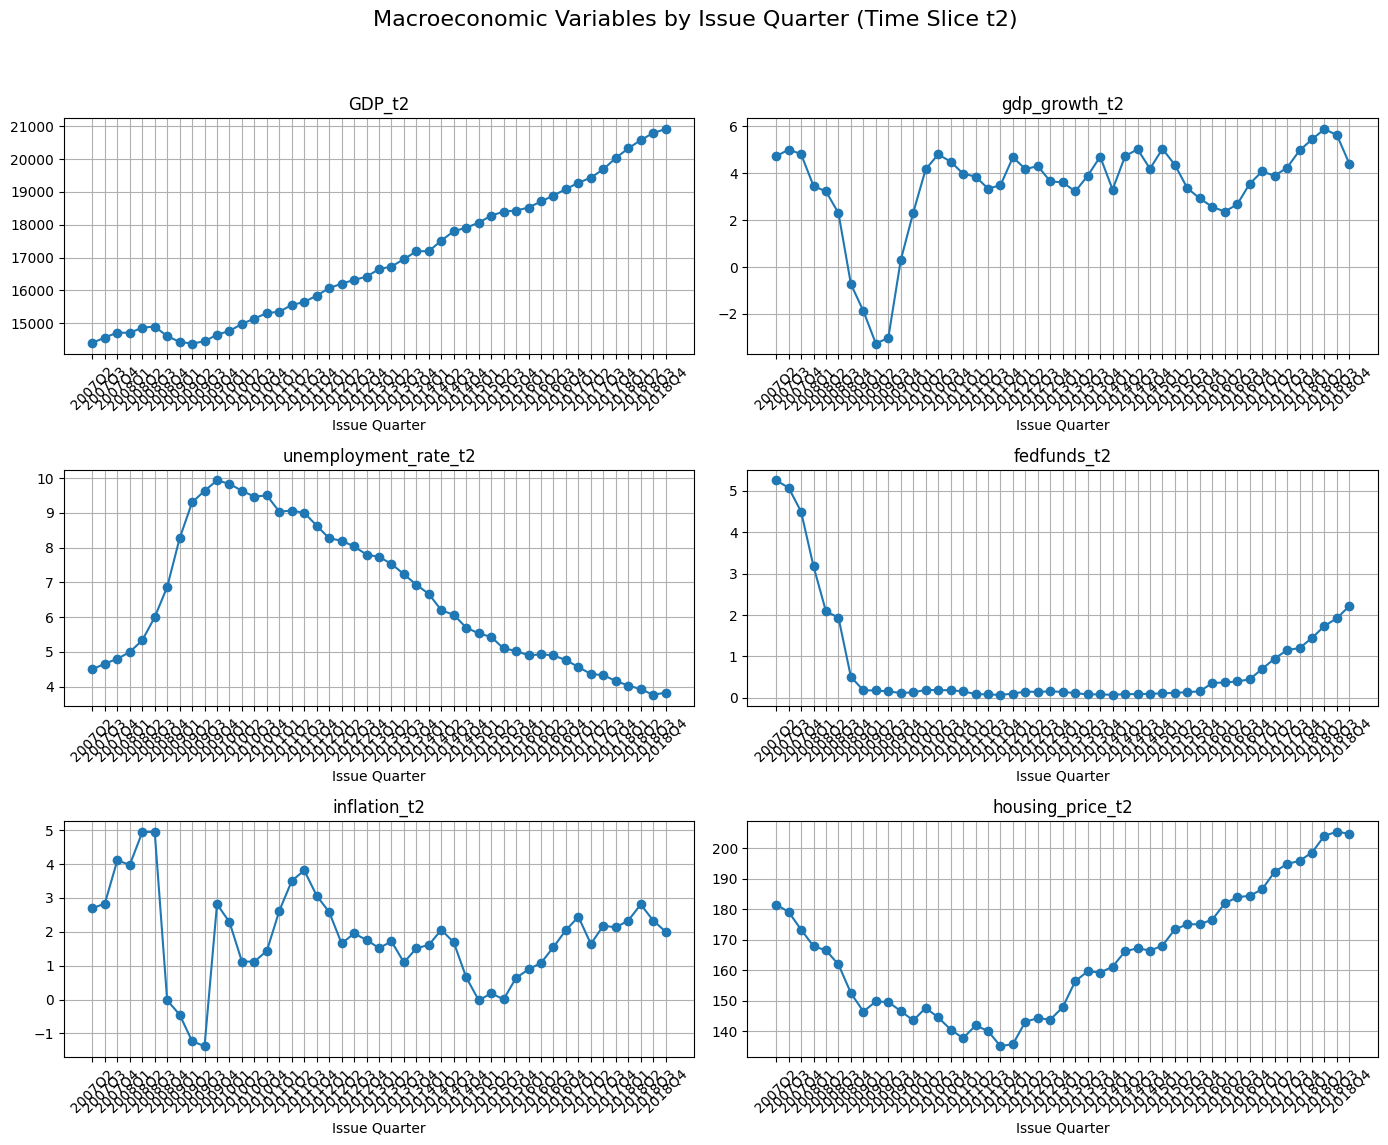

In [9]:
# First, aggregate macro variables by issue_quarter using time slice 2.
agg_macro = df.groupby('issue_quarter').agg({
    'GDP_t2': 'mean',
    'gdp_growth_t2': 'mean',
    'unemployment_rate_t2': 'mean',
    'fedfunds_t2': 'mean',
    'inflation_t2': 'mean',
    'housing_price_t2': 'mean'
}).reset_index()

# Set up a multi-panel plot.
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Macroeconomic Variables by Issue Quarter (Time Slice t2)", fontsize=16)

variables = ['GDP_t2', 'gdp_growth_t2', 'unemployment_rate_t2', 'fedfunds_t2', 'inflation_t2', 'housing_price_t2']
for ax, var in zip(axs.flatten(), variables):
    ax.plot(agg_macro['issue_quarter'], agg_macro[var], marker='o')
    ax.set_title(var)
    ax.set_xlabel("Issue Quarter")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
